Código adaptado de:

[1] D. Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

[2] A. Nandan, Text generation with a miniature GPT, disponível no site do Keras [(link)](https://keras.io/examples/generative/text_generation_with_miniature_gpt/).

# Laboratório 6: Modelos auto-regressivos (utilizando  Transformadores)

## Bibliotecas

### Instalação do `torchinfo`

A célula a seguir instala o pacote `torchinfo`, usado mais adiante para visualizar a arquitetura do modelo.

In [ ]:
!pip install torchinfo

### Importação das bibliotecas

Esta célula importa as bibliotecas necessárias para o laboratório. O PyTorch será usado para definir e treinar o MiniGPT; o TensorFlow/Keras será usado apenas na etapa de tokenização por meio de `TextVectorization`. Também são importados pacotes auxiliares para leitura dos dados, expressões regulares, visualização, barra de progresso e resumo da arquitetura.

In [ ]:
import os                                         # módulo para interagir com o sistema de arquivos (criar pastas, ler arquivos, etc.)
import json                                       # leitura e escrita de dados em formato JSON
import re                                         # expressões regulares para limpeza e padronização de texto
import string                                     # utilitários para operações com strings (e.g., lista de pontuações)
import numpy as np                                # biblioteca para cálculo numérico e operações com arrays
import torch                                      # PyTorch: framework de aprendizado profundo
import torch.nn as nn                             # módulos de construção de redes neurais (camadas, funções de perda, etc.)
from torch.utils.data import Dataset, DataLoader  # abstrações para conjuntos de dados e carregamento de dados
from torch.utils.data import random_split         # utilitário para dividir um Dataset em subconjuntos (ex.: treinamento/teste)
import torch.nn.functional as F                   # funções de ativação, perda e utilitários funcionais
from torchinfo import summary                     # para exibir o resumo da arquitetura do modelo em PyTorch
import tensorflow as tf                           # importa o TensorFlow (usado aqui principalmente para TextVectorization e pré-processamento)
from tensorflow.keras import layers               # importa o submódulo de camadas do Keras (usado aqui para acesso direto às camadas Keras (ex.: layers.TextVectorization))
import gdown                                      # download de arquivos públicos do Google Drive
from IPython.display import display, HTML         # renderização no notebook (exibir strings/HTML formatado)
from tqdm.auto import tqdm                        # barras de progresso adaptáveis ao ambiente
from typing import Tuple                          # anotações de tipo
import matplotlib.pyplot as plt                   # criação de gráficos

### Verificação da versão do PyTorch

A célula a seguir imprime a versão do PyTorch disponível no ambiente

In [ ]:
print(f'Versão do pytorch: {torch.__version__}.')  # exibe a versão instalada do PyTorch

Versão do pytorch: 2.11.0+cu128.


### Configuração de visualização no notebook

A célula a seguir configura o Colab/Jupyter para exibir gráficos do `matplotlib` diretamente abaixo das células.

In [ ]:
# Configurações do Jupyter/Colab:
%matplotlib inline

## Hiperparâmetros

### Definição dos hiperparâmetros

Esta célula define os principais hiperparâmetros do experimento: tamanho máximo do vocabulário, comprimento das sequências, dimensão dos embeddings, número de cabeças de atenção, dimensão do MLP interno, tamanho do lote, número de épocas e taxa de aprendizado. Esses valores controlam tanto a capacidade do modelo quanto o custo computacional do treinamento.

Em termos gerais, o modelo recebe sequências de comprimento `MAX_LEN` e produz, para cada posição $t$, uma distribuição de probabilidade para o próximo token:

$$
p_\theta(x_{t+1}\mid x_1,\ldots,x_t).
$$

In [ ]:
# Hiper-parâmetros principais
VOCAB_SIZE       = 10_000  # @param {type:"integer"}  # tamanho máximo do vocabulário aprendido pela tokenização
MAX_LEN          = 80      # @param {type:"integer"}  # comprimento base da sequência; no Dataset vira MAX_LEN + 1 para criar "x[:-1]" e "y[1:]"
EMBEDDING_DIM    = 256     # @param {type:"integer"}  # dimensão dos embeddings de token e de posição
N_HEADS          = 2       # @param {type:"integer"}  # número de cabeças de atenção
FEED_FORWARD_DIM = 256     # @param {type:"integer"}  # dimensão do MLP interno do bloco Transformador
SEED             = 42      # @param {type:"integer"}  # semente para reprodutibilidade
BATCH_SIZE       = 32      # @param {type:"integer"}  # número de sequências por lote no DataLoader
EPOCHS           = 25      # @param {type:"integer"}  # número de épocas de treinamento
LEARNING_RATE    = 3e-4    # @param {type:"number"}   # taxa de aprendizado

A célula a seguir escolhe o dispositivo de execução, usando GPU/acelerador quando disponível e CPU caso contrário.

In [ ]:
DEVICE = (                                            # escolhe o dispositivo de treino: acelerador disponível via torch.accelerator ou CPU
    torch.accelerator.current_accelerator().type      # obtém o tipo do acelerador atual (ex.: "cuda", "mps")
    if torch.accelerator.is_available()               # verifica se há algum acelerador disponível
    else "cpu"                                        # fallback seguro para CPU
)

## 1. Carregar os dados [(Wine Reviews)](https://www.kaggle.com/datasets/zynicide/wine-reviews)

### Download do conjunto de dados

A célula a seguir baixa o arquivo JSON com as resenhas de vinhos, caso ele ainda não esteja presente no ambiente. O conjunto de dados será usado como corpus textual para treinar o modelo autoregressivo.

In [ ]:
file_id = '1SIiKHuoU4u_d3Ih-syQizcoZvK3pxz-e'                       # ID do arquivo no Google Drive
url = f'https://drive.google.com/uc?id={file_id}'                    # URL direta para download via gdown
output = 'winemag-data-130k-v2.json'                                # nome do arquivo local onde o JSON será salvo
quiet = False                                                       # controla a verbosidade do gdown

if not os.path.exists(output):                                      # verifica se o arquivo já existe no diretório atual
    gdown.download(url=url, output=output, quiet=quiet)             # se não existir, baixa o arquivo do Drive
else:
    print(f"O arquivo '{output}' já está presente. Nenhum download foi realizado.")     # evita download repetido e informa o usuário

O arquivo 'winemag-data-130k-v2.json' já está presente. Nenhum download foi realizado.


### Leitura do arquivo JSON

A célula a seguir carrega o arquivo JSON para a memória. Cada item do objeto carregado corresponde a uma resenha de vinho com diferentes campos, como país, província, variedade e descrição textual.

In [ ]:
# Abre o arquivo baixado e faz a leitura do conteúdo como JSON
filepath = "./winemag-data-130k-v2.json"                                                    # caminho local do arquivo JSON do dataset
with open(filepath) as json_data:                                                           # abre o arquivo em modo leitura padrão (texto)
    data = json.load(json_data)                                                             # carrega o conteúdo JSON para memória (lista de dicionários)

### Inspeção inicial dos dados

A célula a seguir mostra a estrutura do conjunto de dados carregado. Antes de modelar texto, é importante verificar quais campos existem e qual deles contém a informação textual que será usada para treinar o modelo.

In [ ]:
# Inspeção rápida dos dados
print(f'data: {type(data)}')                       # exibe o tipo do objeto carregado (esperado: list)
print(f'data[0]: {type(data[0])}')                 # exibe o tipo do primeiro elemento (esperado: dict)

# Percorre as chaves e valores do primeiro item do dicionário
for k, v in data[0].items():                       # itera pelos pares (chave, valor) da primeira resenha
    print(f'\t{k}: {v}')                           # imprime cada campo para entender a estrutura do conjunto de dados

data: <class 'list'>
data[0]: <class 'dict'>
	points: 87
	title: Nicosia 2013 Vulkà Bianco  (Etna)
	description: Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, offering unripened apple, citrus and dried sage alongside brisk acidity.
	taster_name: Kerin O’Keefe
	taster_twitter_handle: @kerinokeefe
	price: None
	designation: Vulkà Bianco
	variety: White Blend
	region_1: Etna
	region_2: None
	province: Sicily & Sardinia
	country: Italy
	winery: Nicosia


## 2. Filtrar os dados

### Construção do corpus textual

A célula a seguir filtra os registros incompletos e constrói uma string para cada resenha. O texto final combina metadados estruturados, como país, província e variedade, com a descrição do vinho.

Essa escolha cria exemplos com um formato relativamente regular, como:

```text
    wine review : country : province : variety : description
```

Com isso, o modelo aprende não apenas a gerar descrições, mas também a condicionar o texto inicial por informações como país e variedade.

In [ ]:
# Filtragem
filtered_data = [                     # Cria uma lista (list comprehension)
    "wine review : "                  # >>> Prefixo fixo da string
    + x["country"]                    # >>> País de origem do vinho
    + " : "                           # >>> Separador ":"
    + x["province"]                   # >>> Província / região
    + " : "                           # >>> Separador ":"
    + x["variety"]                    # >>> Variedade da uva
    + " : "                           # >>> Separador ":"
    + x["description"]                # >>> Texto descritivo da resenha
    for x in data                     # Percorre cada dicionário (linha) do JSON
    if x["country"] is not None       # Inclui apenas se o país foi informado
    and x["province"] is not None     # ... e a província também
    and x["variety"] is not None      # ... e a variedade da uva também
    and x["description"] is not None  # ... e há descrição disponível
]

### Contagem das resenhas filtradas

A célula a seguir conta quantas resenhas permaneceram após a filtragem. Esse valor determina o tamanho do corpus efetivamente usado no treinamento.

In [ ]:
# Contagem
n_wines = len(filtered_data)                # Conta quantas resenhas passaram no filtro
print(f"{n_wines} resenhas carregadas.")    # Mostra a quantidade no console

129907 resenhas carregadas.


### Visualização de uma resenha

A célula a seguir exibe um exemplo do corpus filtrado. Essa inspeção ajuda a verificar se o texto está no formato esperado antes da tokenização.

In [ ]:
# Exibição de exemplos
example = filtered_data[25]             # Pega a 26a resenha (índice 25) de exemplo
display(example)                        # Imprime essa resenha para inspeção rápida

'wine review : US : California : Pinot Noir : Oak and earth intermingle around robust aromas of wet forest floor in this vineyard-designated Pinot that hails from a high-elevation site. Small in production, it offers intense, full-bodied raspberry and blackberry steeped in smoky spice and smooth texture.'

## 3. Tokenização

### Pré-processamento da pontuação

Esta célula define uma função que adiciona espaços ao redor de sinais de pontuação e de quebras de linha já presentes no texto. Sinais como `:`, `.`, `,` e `!` passam a ser tratados como tokens separados.

Por exemplo, um trecho como:

```text
    wine review: italy
```

pode ser transformado em uma sequência de tokens mais explícita:

```text
    wine review : italy
```

In [ ]:
# Pré-processamento: inserir espaços ao redor da pontuação
def pad_punctuation(s):                                                         # Define a função que processa a pontuação
    s = re.sub(                                                                 # 1a substituição com expressão regular
        pattern=f"([{string.punctuation}, '\n'])",                              #   - Captura qualquer caractere de pontuação ou quebra de linha
        repl=r" \1 ",                                                           #   - Adiciona um espaço antes e outro depois do caractere capturado
        string=s                                                                #   - string de entrada a ser transformada
    )
    s = re.sub(                                                                 # 2a substituição com expressão regular
        pattern=" +",                                                           #   - Identifica sequências de múltiplos espaços
        repl=" ",                                                               #   - Substitui por um único espaço
        string=s                                                                #   - string de entrada a ser transformada
    )
    return s                                                                    # Retorna a string processada

### Aplicação do pré-processamento

A célula a seguir aplica a função de pré-processamento a todas as resenhas filtradas. O resultado é uma lista de textos padronizados.

In [ ]:
# Aplica a função de pré-processamento a cada resenha previamente filtrada
text_data = [pad_punctuation(x) for x in filtered_data]                         # Cria nova lista com pontuação espaçada

### Verificação do texto pré-processado

A célula a seguir exibe um exemplo após o pré-processamento.

In [ ]:
# Visualização de um exemplo
example_data = text_data[25]                                                    # Seleciona a 26a resenha para inspeção
display(example_data)                                                           # Exibe o resultado

'wine review : US : California : Pinot Noir : Oak and earth intermingle around robust aromas of wet forest floor in this vineyard - designated Pinot that hails from a high - elevation site . Small in production , it offers intense , full - bodied raspberry and blackberry steeped in smoky spice and smooth texture . '

## 4. Classe que encapsula os dados

### Classe WineDataset

A célula a seguir define a classe `WineDataset`, uma subclasse de `torch.utils.data.Dataset`, responsável por transformar o corpus textual em pares de treinamento $(\mathbf{x}, \mathbf{y})$ para modelagem autoregressiva.

A classe usa dois hiperparâmetros definidos no início do notebook:

- `VOCAB_SIZE`: controla o tamanho máximo do vocabulário usado na tokenização;
- `MAX_LEN`: controla o comprimento das sequências de entrada e alvo usadas no treinamento.

Os principais métodos da classe são:

- `__init__`: cria a camada `TextVectorization` para converter texto em sequências de índices inteiros. Essa camada é configurada para:

  - converter o texto para minúsculas;
  - limitar o tamanho máximo do vocabulário a `VOCAB_SIZE`, selecionando os tokens mais frequentes do corpus;
  - gerar sequências de comprimento fixo `MAX_LEN + 1`, usando padding ou truncamento quando necessário.

O uso de `MAX_LEN + 1` é necessário porque, antes de formar os pares $(\mathbf{x}, \mathbf{y})$, cada sequência precisa ter um token a mais. Esse token adicional permite criar uma entrada de tamanho `MAX_LEN` e um alvo também de tamanho `MAX_LEN` após o deslocamento.

Em seguida, o método `adapt(texto)` faz a camada aprender o vocabulário a partir do corpus. Depois disso, cada texto é vetorizado, isto é, transformado em uma sequência numérica da forma:

$$
(\mathrm{ID}_1,\mathrm{ID}_2,\ldots,\mathrm{ID}_T),
$$

em que cada $\mathrm{ID}_t$ representa o índice inteiro de um token no vocabulário.

A partir dessas sequências tokenizadas, são construídos os pares de entrada e alvo por deslocamento de (1) posição:

$$
\mathbf{x} = (\mathrm{ID}_1,\mathrm{ID}_2,\ldots,\mathrm{ID}_{T-1}),
\qquad
\mathbf{y} = (\mathrm{ID}_2,\mathrm{ID}_3,\ldots,\mathrm{ID}_T).
$$

Como a sequência vetorizada tem comprimento `MAX_LEN + 1`, tanto `x` quanto `y` ficam com comprimento `MAX_LEN`. Assim, em cada posição, o alvo contém o próximo token da sequência. Em outras palavras, o modelo recebe uma sequência de tokens em `x` e é treinado para prever, posição a posição, os tokens seguintes em `y`.

- `__len__`: retorna o número total de sequências do dataset.

- `__getitem__`: recebe um índice `idx` e retorna o par correspondente $(\mathbf{x}_{\text{idx}}, \mathbf{y}_{\text{idx}})$, isto é, uma sequência de entrada tokenizada e sua respectiva sequência-alvo.

Os métodos `__len__` e `__getitem__` permitem que a classe seja usada diretamente com um `DataLoader` do PyTorch durante o treinamento.

In [ ]:
class WineDataset(Dataset):
    """
    Dataset PyTorch para modelagem autoregressiva usando tokenização do Keras.

    Este dataset:
    1. Cria e adapta uma camada `TextVectorization` ao texto bruto.
    2. Vetoriza todas as sequências com padding/truncamento fixo.
    3. Constrói pares (x, y) por deslocamento de 1 token:
       - x = sequência sem o último token
       - y = sequência sem o primeiro token
    4. Retorna tensores PyTorch prontos para treinar um modelo do tipo decoder-only.

    Parameters
    ----------
    texto : list[str]
        Lista de strings contendo o corpus já filtrado.
    max_tokens : int, optional
        Tamanho máximo do vocabulário a ser aprendido pela `TextVectorization`.
        Default: VOCAB_SIZE.
    output_sequence_length : int, optional
        Comprimento fixo da sequência gerada pela vetorização.
        Tipicamente deve ser MAX_LEN + 1 para permitir o deslocamento que gera x e y de tamanho MAX_LEN.
        Default: MAX_LEN + 1.

    Attributes
    ----------
    vectorize_layer : tf.keras.layers.TextVectorization
        Camada responsável por aprender o vocabulário e converter texto em sequências de índices.
    x : torch.Tensor
        Tensores de entrada com shape (N, MAX_LEN), contendo tokens de 0 até o penúltimo.
    y : torch.Tensor
        Tensores-alvo com shape (N, MAX_LEN), contendo tokens do segundo até o último.

    Notes
    -----
    O índice 0 corresponde ao token de padding e o índice 1 ao token "[UNK]".
    """

    def __init__(
        self,
        texto: list[str],
        max_tokens: int = VOCAB_SIZE,
        output_sequence_length: int = MAX_LEN + 1
    ) -> None:
        # cria a camada de vetorização: minúsculas + vocabulário limitado + saída inteira + comprimento fixo
        self.vectorize_layer = layers.TextVectorization(                        # Instancia TextVectorization
            standardize="lower",                                                # padroniza texto convertendo para minúsculas
            max_tokens=max_tokens,                                              # limita o vocabulário aos "max_tokens" tokens mais frequentes
            output_mode="int",                                                  # retorna sequência de índices inteiros
            output_sequence_length=output_sequence_length,                      # comprimento fixo da sequência: MAX_LEN + 1 (padding/truncamento)
        )

        self.vectorize_layer.adapt(texto)                                       # aprende o vocabulário percorrendo todo o corpus

        # vetoriza todo o texto (transforma em valores numéricos)): TF -> NumPy -> Torch, shape esperado (N, MAX_LEN + 1)
        tokenized_sentences = torch.from_numpy(self.vectorize_layer(texto).numpy().astype(np.int64)).long()

        # separa entrada (x) e alvo (y) por deslocamento de 1 token
        self.x: torch.Tensor = tokenized_sentences[:, :-1]                      # entradas (x = sequência sem o último token): remove o último token -> (N, MAX_LEN)
        self.y: torch.Tensor = tokenized_sentences[:, 1:]                       # alvos  (y = sequência sem o primeiro token): remove o primeiro token -> (N, MAX_LEN)

    # ----------------------------------------------------------------
    # Métodos obrigatórios do `torch.utils.data.Dataset`
    # ----------------------------------------------------------------
    def __len__(self) -> int:
        return self.x.shape[0]                                                  # retorna N, o número total de sequências

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.x[idx], self.y[idx]                                         # retorna (x, y) como (entrada_tokenizada, alvo_tokenizado)

### Criação dos conjuntos de treinamento e teste

A célula a seguir instancia o dataset e divide os exemplos em treinamento e teste. A semente fixa em `random_split` torna a divisão reprodutível.

In [ ]:
# Instancia o Dataset e o DataLoader

# cria o dataset a partir da lista de strings
dataset = WineDataset(texto=text_data)

N = len(dataset)                                                                # número total de exemplos disponíveis no dataset completo
N_train = int(0.9 * N)                                                          # define 90% dos exemplos para o conjunto de treinamento
N_test  = N - N_train                                                           # define os 10% restantes para o conjunto de teste

train_ds, test_ds = random_split(
    dataset,
    [N_train, N_test],                                                          # tamanhos desejados para os subconjuntos (treinamento e teste)
    generator=torch.Generator().manual_seed(42)                                 # fixa a semente para obter sempre o mesmo split (reprodutibilidade)
)

### Criação dos `DataLoaders`

A célula a seguir cria os carregadores de dados usados no treinamento e na avaliação do modelo.

O `DataLoader` de treinamento usa `shuffle=True`, embaralhando os exemplos a cada época para reduzir a dependência da ordem dos dados. O tamanho dos lotes é controlado pelo hiperparâmetro `BATCH_SIZE`, definido no início do notebook.

O `DataLoader` de teste usa `shuffle=False`, pois nessa etapa não é necessário embaralhar os exemplos; queremos apenas avaliar o modelo.

Cada lote contém tensores `x` e `y` com forma `[B, S]`, onde `B` é o tamanho do lote e `S` é o comprimento da sequência. Neste experimento, `S` corresponde a `MAX_LEN`.

In [ ]:
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)    # DataLoader de treinamento: agrupa exemplos em lotes e embaralha a cada época
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)  # DataLoader de teste: agrupa exemplos em lotes, mantendo a ordem fixa

### Conferência dos tamanhos dos conjuntos

A célula a seguir imprime o número total de exemplos, além dos tamanhos dos conjuntos de treinamento e teste.

In [ ]:
print(f"N total:  {N}")
print(f"N treinamento: {len(train_ds)}")
print(f"N teste:  {len(test_ds)}")

N total:  129907
N treinamento: 116916
N teste:  12991


### Entrada tokenizada

A célula a seguir mostra um exemplo de entrada `x` tokenizada. Cada número corresponde ao índice de um token no vocabulário aprendido pela camada `TextVectorization`.

In [ ]:
dataset.x[25]  # x tokenizado

tensor([   7,   10,    2,   20,    2,   29,    2,   43,   62,    2,   55,    5,
         243, 4145,  453,  634,   26,    9,  497,  499,  667,   17,   12,  142,
          14, 2214,   43,   25, 2484,   32,    8,  223,   14, 2213,  948,    4,
         594,   17,  987,    3,   15,   75,  237,    3,   64,   14,   82,   97,
           5,   74, 2633,   17,  198,   49,    5,  125,   77,    4,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

### Alvo tokenizado

A célula a seguir mostra o alvo `y` correspondente ao exemplo anterior. Ele é a mesma sequência deslocada uma posição à frente, pois o objetivo do modelo é predizer o próximo token a partir dos tokens anteriores.

In [ ]:
dataset.y[25]  # y tokenizado

tensor([  10,    2,   20,    2,   29,    2,   43,   62,    2,   55,    5,  243,
        4145,  453,  634,   26,    9,  497,  499,  667,   17,   12,  142,   14,
        2214,   43,   25, 2484,   32,    8,  223,   14, 2213,  948,    4,  594,
          17,  987,    3,   15,   75,  237,    3,   64,   14,   82,   97,    5,
          74, 2633,   17,  198,   49,    5,  125,   77,    4,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

### Número de exemplos no dataset

A célula a seguir imprime a quantidade total de sequências tokenizadas disponíveis no dataset. Esse valor corresponde ao número de exemplos que podem ser usados para treinamento e avaliação.

In [ ]:
print(f'Número de exemplos do conjunto de dados: {len(dataset)}')               # exibe N (quantidade total de sequências tokenizadas no dataset)

Número de exemplos do conjunto de dados: 129907


### Recuperação do vocabulário

A célula a seguir obtém o vocabulário aprendido na tokenização. O vocabulário é uma lista em que a posição do item é o índice usado nos tensores tokenizados.

Assim, se `vocab[i] = palavra`, então o índice `i` representa essa palavra ou token no modelo.

In [ ]:
vocab = dataset.vectorize_layer.get_vocabulary()                                # vocabulário: lista de tokens do vocabulário aprendido pela TextVectorization (índice -> token)
print(f'vocab: {type(vocab)}')                                                  # confirma o tipo do vocabulário (esperado: list)
print(f'vocab[0]: {type(vocab[0])}')                                            # confirma o tipo de cada item (esperado: str)

vocab: <class 'list'>
vocab[0]: <class 'str'>


### Visualização dos primeiros tokens do vocabulário

A célula a seguir imprime alguns pares índice-token do vocabulário.

In [ ]:
# Visualiza algumas correspondências "índice: palavra"
for i, word in enumerate(vocab[:10]):                                           # Percorre os 10 primeiros itens do vocabulário
    print(f"{i}: {word}")                                                       # Imprime "índice: palavra" no console

0: 
1: [UNK]
2: :
3: ,
4: .
5: and
6: the
7: wine
8: a
9: of


## 5. Modelo

### Embeddings de token e posição

### Camada `TokenAndPositionEmbedding`

A célula a seguir define a classe `TokenAndPositionEmbedding`, uma subclasse de `torch.nn.Module`, responsável por transformar sequências de IDs de tokens em vetores densos que combinam informação de conteúdo e informação de posição.

A classe usa três hiperparâmetros definidos no início do notebook:

- `VOCAB_SIZE`: controla o número máximo de IDs de tokens que podem ser representados;
- `MAX_LEN`: controla o número máximo de posições representáveis na sequência;
- `EMBEDDING_DIM`: controla a dimensão dos vetores de embedding.

Os principais métodos da classe são:

- `__init__`: cria duas camadas de embedding treináveis:

  - `token_emb`: transforma cada ID de token em um vetor de dimensão `EMBEDDING_DIM`;
  - `pos_emb`: transforma cada posição da sequência em um vetor de dimensão `EMBEDDING_DIM`.

    Essas duas camadas podem ser vistas como **tabelas treináveis**:
    
    $E_{\text{token}} \in \mathbb{R}^{\text{VOCAB\_SIZE} \times \text{EMBEDDING\_DIM}}, \qquad E_{\text{pos}} \in \mathbb{R}^{\text{MAX\_LEN} \times \text{EMBEDDING\_DIM}}.$

    A primeira tabela armazena os vetores associados aos tokens do vocabulário. A segunda tabela armazena os vetores associados às posições da sequência.

     **Exemplo.**
     
     Se `EMBEDDING_DIM = 4`, poderíamos visualizar parte de `token_emb` como:

    | ID do token | Token | Vetor de embedding |
    |---:|:---|:---|
    | 0 | `[PAD]` | $(0.12, -0.08, 0.31, 0.05)$ |
    | 1 | `[UNK]` | $(-0.20, 0.14, 0.07, -0.11)$ |
    | 2 | `wine` | $(0.44, 0.03, -0.18, 0.27)$ |
    | 3 | `italy` | $(0.09, -0.35, 0.22, 0.16)$ |

     Se `MAX_LEN = 5` e `EMBEDDING_DIM = 4`, poderíamos visualizar parte de `pos_emb` como:

    | Posição | Vetor de embedding posicional |
    |---:|:---|
    | 0 | $(0.01, 0.21, -0.04, 0.17)$ |
    | 1 | $(-0.13, 0.08, 0.19, -0.02)$ |
    | 2 | $(0.25, -0.06, 0.03, 0.11)$ |
    | 3 | $(0.07, 0.14, -0.20, 0.05)$ |
    | 4 | $(-0.09, 0.02, 0.16, 0.23)$ |

    Os valores nas tabelas acima são apenas ilustrativos. No modelo real, esses vetores são parâmetros treináveis, isto é, são ajustados durante o treinamento por retropropagação. Note que ID do token $\neq$ Posição, isto é, O ID identifica **qual token** está naquela posição; a posição identifica **onde esse token aparece na sequência**.

- `forward`: recebe um tensor `x` contendo IDs de tokens, com forma `[B, S]`, onde `B` é o tamanho do lote e `S` é o comprimento da sequência.

    A partir de `S`, o método constrói os índices de posição:

   $(0,1,\ldots,S-1),$

    replicando esses índices para todos os exemplos do lote. Em seguida, a classe obtém os embeddings de token e os embeddings posicionais acessando esses valores nas "tabelas":

   $\text{token_embeddings} = E_{\text{token}}(x), \qquad \text{pos_embeddings} = E_{\text{pos}}(\text{positions}).$

    Ambos os tensores têm forma `[B, S, D]`, onde `D = EMBEDDING_DIM`. Como eles têm a mesma forma, podem ser somados posição a posição:

   $\mathbf{z}_t = E_{\text{token}}(\mathrm{ID}_t) +E_{\text{pos}}(t).$

   Nessa expressão, $\mathrm{ID}_t$ é o ID do token na posição $t$, enquanto $t$ indica a posição desse token na sequência. O embedding de token representa o conteúdo do token; o embedding posicional informa sua posição na sequência.

   O resultado final do método `forward` é um tensor com forma `[B, S, D]`, que será usado como entrada para o bloco Transformer.

- `extra_repr`: define uma representação textual auxiliar da camada, mostrando os valores de `max_len`, `vocab_size` e `embed_dim` quando o módulo é impresso ou inspecionado.

A soma entre embeddings de token e embeddings posicionais é importante porque a autoatenção, sozinha, não possui uma noção explícita da ordem dos tokens. Portanto, os embeddings posicionais fornecem ao modelo informação sobre a organização sequencial do texto.

In [ ]:
class TokenAndPositionEmbedding(nn.Module):
    """
    Camada que combina embedding de tokens e embedding posicional por soma.

    A soma exige que os embeddings de token e posição tenham a mesma dimensão.

    Parameters
    ----------
    max_len : int
        Comprimento máximo das sequências / número máximo de posições representáveis.
    vocab_size : int
        Tamanho do vocabulário (número máximo de tokens distintos).
    embed_dim : int
        Dimensão dos vetores de embedding para tokens e posições.

    Attributes
    ----------
    max_len : int
        Armazena o comprimento máximo da sequência.
    vocab_size : int
        Armazena o tamanho do vocabulário.
    embed_dim : int
        Armazena a dimensão do embedding.
    token_emb : nn.Embedding
        Embedding de tokens: índices de tokens -> vetores de dimensão embed_dim.
    pos_emb : nn.Embedding
        Embedding posicional: índices de posição -> vetores de dimensão embed_dim.
    """

    def __init__(self, max_len: int, vocab_size: int, embed_dim: int) -> None:

        super().__init__()            # inicializa a base nn.Module
        self.max_len = max_len        # comprimento máximo da sequência
        self.vocab_size = vocab_size  # tamanho do vocabulário
        self.embed_dim = embed_dim    # dimensão dos embeddings (token e posição)

        # Camada de embedding de tokens (treinável)
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)

        # Camada de embedding posicional (treinável)
        self.pos_emb = nn.Embedding(num_embeddings=max_len, embedding_dim=embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Propagação direta.
        Soma embeddings de token e posição.

        Parameters
        ----------
        x : torch.Tensor
            Tensor de entrada contendo índices de tokens com shape (B, S),
            onde B = tamanho do lotes e S = comprimento da sequências.

        Returns
        -------
        torch.Tensor
            Embeddings combinados com shape (B, S, D),
            onde D = dimensão dos embeddings.
        """

        B, S = x.shape                                          # x: (B, S) -> extrai o tamanho do lote (B) e comprimento da sequência (S)

        positions = (                                           # constrói índices de posição para cada elemento do lote
            torch.arange(S, device=x.device)                    # cria [0, 1, ..., S-1] -> shape (S,)
            .unsqueeze(0)                                       # adiciona dimensão de lote -> shape (1, S)
            .expand(B, S)                                       # replica para cada item do lote -> shape (B, S)
        )

        token_embeddings = self.token_emb(x)                    # aplica embedding de tokens: (B, S) -> (B, S, D)
        pos_embeddings = self.pos_emb(positions)                # aplica embedding posicional: (B, S) -> (B, S, D)

        return token_embeddings + pos_embeddings                # combina informação semântica + ordem temporal por soma

    def extra_repr(self) -> str:
        return (                                                # define string extra para print/summary do módulo
            f"max_len={self.max_len}, "
            f"vocab_size={self.vocab_size}, "
            f"embed_dim={self.embed_dim}"
        )


## Bloco Transformador

A célula a seguir define a classe `MaskedTransformerLayer`, uma subclasse de `torch.nn.Module`, que implementa um bloco Transformer simplificado do tipo *decoder-only*. Esse é o tipo de bloco usado em modelos GPT: cada posição da sequência pode usar apenas informações dela mesma e das posições anteriores.

A classe usa hiperparâmetros definidos no início do notebook:

- `EMBEDDING_DIM`: controla a dimensão dos vetores que entram e saem do bloco Transformer;
- `N_HEADS`: controla o número de cabeças de atenção na camada de autoatenção múltipla;
- `FEED_FORWARD_DIM`: controla a dimensão intermediária da MLP interna do bloco.

Os principais métodos da classe são:

- `__init__`: cria os componentes internos do bloco Transformer:

  - `attn`: camada de autoatenção de múltiplas cabeças, implementada por `nn.MultiheadAttention`;
  - `layer_norm_1`: normalização por camada aplicada após a conexão residual da atenção;
  - `mlp`: rede feed-forward compartilhada e aplicada separadamente a cada posição da sequência;
  - `layer_norm_2`: normalização por camada aplicada após a conexão residual da MLP.

A camada de autoatenção recebe um tensor com forma `[B, S, D]`, onde `B` é o tamanho do lote, `S` é o comprimento da sequência e `D = EMBEDDING_DIM`. Como o argumento `batch_first=True` foi usado, a primeira dimensão do tensor corresponde ao lote.

Na autoatenção, o próprio tensor de entrada é usado para formar consultas [*queries*], chaves [*keys*] e valores [*values*]. De forma simplificada:

$Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V,$

em que $X$ representa as entradas do bloco e $W_Q$, $W_K$ e $W_V$ são matrizes de parâmetros treináveis. A atenção calcula combinações ponderadas dos vetores de valor:

$\mathrm{Attention}(Q,K,V) = \mathrm{softmax} \left( \dfrac{QK^\top}{\sqrt{d}} \right)V.$

A intuição é que cada posição da sequência aprende a atribuir pesos às demais posições permitidas, combinando informações relevantes do contexto.

- `_causal_mask`: cria uma máscara causal booleana com forma `[S, S]`.

     Essa máscara impede que uma posição acesse posições futuras.
     
     **Exemplo.** Para uma sequência com `S = 5`, a máscara pode ser visualizada como:     

   | Posição que consulta | pos. 0 | pos. 1 | pos. 2 | pos. 3 | pos. 4 |
   |---:|:---:|:---:|:---:|:---:|:---:|
   | 0 | ✅ | ❌ | ❌ | ❌ | ❌ |
   | 1 | ✅ | ✅ | ❌ | ❌ | ❌ |
   | 2 | ✅ | ✅ | ✅ | ❌ | ❌ |
   | 3 | ✅ | ✅ | ✅ | ✅ | ❌ |
   | 4 | ✅ | ✅ | ✅ | ✅ | ✅ |

   ✅ indica que a posição pode ser usada na atenção

   ❌ indica que a posição está bloqueada pela máscara causal.

  No código, essa máscara é construída com `torch.triu(..., diagonal=1)`. Em termos práticos, as posições acima da diagonal principal correspondem a tokens futuros e são bloqueadas. No PyTorch, nesse tipo de máscara booleana, `True` indica posições mascaradas, isto é, posições que não podem ser usadas na atenção.

  Assim, durante o treinamento autoregressivo, a posição $t$ só pode usar informações das posições $0,1,\ldots,t$. Isso é essencial para que o modelo aprenda a estimar:

  $p_\theta(\mathrm{ID}_{t+1} \mid \mathrm{ID}_1,\ldots,\mathrm{ID}_t),$

   sem acessar diretamente os próximos tokens da sequência.

- `forward`: executa a propagação direta do bloco Transformer.

   Primeiro, o método recebe um tensor `x` com forma `[B, S, D]` e cria a máscara causal correspondente ao comprimento `S` da sequência. Em seguida, aplica a autoatenção causal:

   $A = \mathrm{CausalSelfAttention}(X).$

   Depois disso, o bloco aplica a primeira conexão residual seguida de normalização:

   $Z = \mathrm{LayerNorm}(X + A).$

   A conexão residual soma a entrada original $X$ à saída da atenção. Isso ajuda o fluxo de informação e de gradientes durante o treinamento.

   Em seguida, o tensor $Z$ passa por uma MLP aplicada posição a posição:

   $M = \mathrm{MLP}(Z).$

  Por fim, o bloco aplica a segunda conexão residual seguida de normalização:

  $X_{\text{out}} = \mathrm{LayerNorm}(Z + M).$

  Portanto, o bloco preserva a forma do tensor:

  $[B,S,D] \longrightarrow [B,S,D].$

Além da saída `x_out`, o método `forward` também retorna `attn_output_weights`, que contém os pesos de atenção. Esses pesos podem ser usados para visualizar quais posições da sequência receberam mais atenção durante o processamento.

Em resumo, esse bloco combina três ideias centrais dos Transformadores do tipo *decoder-only*:

1. **autoatenção causal**, para modelar dependências entre tokens sem acessar o futuro;
2. **conexões residuais**, para facilitar o treinamento de redes profundas;
3. **normalização por camada e MLP**, para aumentar a flexibilidade do transformador.

In [ ]:
class MaskedTransformerLayer(nn.Module):
    """
    Bloco Transformer (do tipo decoder-only) com máscara causal.

    Este bloco implementa:
    1) Autoatenção com máscara causal (impede acesso a tokens futuros).
    2) Conexão residual + normalização por camada.
    3) MLP posição-a-posição (feed-forward) + conexão residual + normalização por camada.

    Parameters
    ----------
    embed_dim : int
        Dimensão dos vetores de embedding e atenção.
    num_heads : int
        Número de cabeças de atenção múltipla.
    ff_dim : int
        Dimensão da camada intermediária no MLP.
    dropout : float, optional
        Taxa de dropout aplicada à camada de atenção e ao MLP. Default: 0.1.

    Attributes
    ----------
    attn : nn.MultiheadAttention
        Camada de autoatenção múltipla que opera sobre (batch_size, seq_len, embed_dim).
    layer_norm_1 : nn.LayerNorm
        Normalização por camada aplicada após o bloco de atenção.
    mlp : nn.Sequential
        Rede MLP interna (Linear → ReLU → Linear → Dropout).
    layer_norm_2 : nn.LayerNorm
        Normalização por camada aplicada após o bloco de MLP.

    Notes
    -----
    A máscara causal impede que cada token no passo t "veja" tokens em posições > t.
    """

    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, dropout: float = 0.1) -> None:

        super().__init__()                                                      # inicializa a base nn.Module

        # self.attn: Autoatenção de múltiplas cabeças usando x como Q, K e V
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,                                                # dimensão dos vetores de entrada/saída da atenção
            num_heads=num_heads,                                                # número de cabeças de atenção
            dropout=dropout,                                                    # dropout aplicado internamente pela atenção
            batch_first=True                                                    # formato esperado: (B, S, D)
        )

        # self.layer_norm_1: normalização aplicada após a conexão residual da atenção
        self.layer_norm_1 = nn.LayerNorm(embed_dim)                             # Normalização por Camada 1

        # self.mlp: rede feed-forward aplicada a cada token (Linear → ReLU → Linear → Dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),                                       # projeta D -> ff_dim
            nn.ReLU(),                                                          # não-linearidade do MLP
            nn.Linear(ff_dim, embed_dim),                                       # projeta ff_dim -> D
            nn.Dropout(dropout)                                                 # dropout na saída do MLP (regularização)
        )

        # self.layer_norm_2: normalização aplicada após a conexão residual do MLP
        self.layer_norm_2 = nn.LayerNorm(embed_dim)                             # Normalização por Camada 2

    @staticmethod
    def _causal_mask(sz: int, device: torch.device | None = None) -> torch.Tensor:
        """
        Cria máscara causal booleana com shape (sz, sz).

        Parameters
        ----------
        sz : int
            Comprimento da sequência (S).
        device : torch.device | None, optional
            Dispositivo onde a máscara será criada.

        Returns
        -------
        torch.Tensor
            Máscara booleana triangular superior:
            True  -> posições mascaradas (futuras),
            False -> posições permitidas.
        """
        return torch.triu(
            torch.ones(sz, sz, dtype=torch.bool, device=device),  # matriz cheia de True/1
            diagonal=1                                            # zera diagonal principal e parte inferior
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Propagação direta do bloco Transformador (mascarado).

        Parameters
        ----------
        x : torch.Tensor
            Entrada com shape (B, S, D), onde:
            B = tamanho do lote, S = comprimento da sequência, D = dimensão dos embeddings.

        Returns
        -------
        x_out : torch.Tensor
            Saída do bloco com shape (B, S, D).
        attn_output_weights : torch.Tensor
            Pesos de atenção. Pode ter forma (B, H, S, S) ou (B, S, S), dependendo da configuração de heads
            (onde H é o número de cabeças de atenção). Pesos de atenção médios entre cabeças com shape (B, S, S)
            quando average_attn_weights=True.
        """

        seq_len = x.shape[1]                                                    # x tem shape (B, S, D) -> extrai o comprimento da sequência (S)

        attn_mask = self._causal_mask(seq_len, x.device)                        # máscara causal com shape (S, S)


        attn_output, attn_output_weights = self.attn(                           # Aplica a camada de autoatenção causal de múltiplas cabeças
            x,                                                                  # Query = x
            x,                                                                  # Key   = x
            x,                                                                  # Value = x
            attn_mask=attn_mask,                                                # impede atenção a tokens futuros
            need_weights=True,                                                  # retorna pesos de atenção
            average_attn_weights=True                                           # retorna média dos pesos entre cabeças
        )

        # Bloco "Add & Norm" (#1):
        #   1. Conexão residual: x (entrada original) + attn_output (saída da atenção).
        #   2. LayerNorm: normaliza a soma resultante ao longo da dimensão embed_dim.
        z = self.layer_norm_1(x + attn_output)                                  # Add & Norm #1: residual da atenção

        mlp_output = self.mlp(z)                                                # Aplica a rede MLP sobre z: (B, S, D) -> (B, S, D)

        # Bloco "Add & Norm" (#2):
        #   1. Conexão residual: z (entrada ao bloco MLP) + mlp_output (saída da rede MLP).
        #   2. LayerNorm: normaliza a soma resultante ao longo da dimensão embed_dim.
        x_out = self.layer_norm_2(z + mlp_output)                               # Add & Norm #2: residual do MLP

        return x_out, attn_output_weights                                       # retorna (saída do bloco, pesos de atenção)

## Camada Linear-LogSoftmax



### Projeção para o vocabulário

A célula a seguir define a classe `LSM`, uma subclasse de `torch.nn.Module`, responsável por projetar as representações do Transformer para o vocabulário e converter os *logits* resultantes em log-probabilidades.

Essa camada usa dois hiperparâmetros definidos no início do notebook:

- `EMBEDDING_DIM`: controla a dimensão dos vetores que vêm do bloco Transformer;
- `VOCAB_SIZE`: controla o tamanho do vocabulário, isto é, o número de possíveis tokens que o modelo pode prever.

Os principais métodos da classe são:

- `__init__`: cria duas etapas:

  - `linear`: camada linear que projeta cada vetor de dimensão `EMBEDDING_DIM` para um vetor de dimensão `VOCAB_SIZE`;
  - `log_softmax`: camada que transforma os *logits* produzidos pela camada linear em log-probabilidades.

  A camada linear pode ser vista como uma projeção do espaço interno do modelo para o espaço dos tokens do vocabulário:

  $\mathbb{R}^{\text{EMBEDDING_DIM}} \longrightarrow \mathbb{R}^{\text{VOCAB_SIZE}}.$

  Assim, para cada posição da sequência, o modelo produz um vetor de `VOCAB_SIZE` *logits*, isto é, valores reais ainda não normalizados, um para cada possível próximo token do vocabulário.

  **Exemplo.**
  
  Se `VOCAB_SIZE = 10000`, então cada posição da sequência terá `10000` logits: um para cada possível próximo token.

- `forward`: recebe um tensor `x` com as representações produzidas pelo Transformer.

  Se a entrada tem forma `[B, S, D]`, onde `D = EMBEDDING_DIM`, a camada linear atua sobre a última dimensão e produz:

  $[B,S,D] \longrightarrow [B,S,V],$

  onde `V = VOCAB_SIZE`.

  Em seguida, `LogSoftmax(dim=-1)` é aplicado sobre a última dimensão, isto é, sobre a dimensão do vocabulário. Dessa forma, para cada exemplo do lote e para cada posição da sequência, o modelo fornece um vetor de log-probabilidades sobre todos os tokens possíveis:

  $\log p_\theta(\mathrm{ID}_{t+1}=j \mid \mathrm{ID}_1,\ldots,\mathrm{ID}_t), \qquad j=0,\ldots,V-1.$

  O uso de `dim=-1` é importante porque indica que a normalização deve ser feita sobre os tokens do vocabulário, e não sobre a dimensão do lote ou da sequência.

De forma simplificada, o fluxo da camada é:

$$
\text{representação do Transformer}
\rightarrow
\text{logits}
\rightarrow
\text{log-probabilidades}.
$$

Ou, em termos de formas dos tensores:

$$
[B,S,\text{EMBEDDING_DIM}]
\rightarrow
[B,S,\text{VOCAB_SIZE}]
\rightarrow
[B,S,\text{VOCAB_SIZE}].
$$

A saída da classe `LSM` é usada no cálculo da função de perda `NLLLoss`, após a reorganização das dimensões dos tensores. Essa função espera receber log-probabilidades e as compara com o próximo token correto em cada posição da sequência.

In [ ]:
class LSM(nn.Module):
    """
    Aplica Linear seguido de LogSoftmax.

    Parameters
    ----------
    embed_dim : int
        Dimensão de entrada (tamanho do embedding vindo do Transformer).
    vocab_size : int
        Número de classes (tamanho do vocabulário).
    bias : bool, optional
        Se a camada Linear deve ter viés (bias). Default: False.
    """

    def __init__(self, embed_dim: int, vocab_size: int, bias: bool = False) -> None:

        super().__init__()

        # Projeta de embed_dim para vocab_size (logits)
        self.linear = nn.Linear(in_features=embed_dim, out_features=vocab_size, bias=bias)

        # Converte logits em log-probabilidades
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : torch.Tensor
            Tensor de entrada com shape (..., embed_dim).

        Returns
        -------
        torch.Tensor
            Log-probabilidades com shape (..., vocab_size).
        """

        logits = self.linear(x)

        return self.log_softmax(logits)

## MiniGPT

### Arquitetura `GPTMini`

A célula a seguir define a classe `GPTMini`, uma subclasse de `torch.nn.Module`, responsável por combinar as camadas anteriores em um modelo autoregressivo simplificado do tipo GPT.

A classe usa hiperparâmetros definidos no início do notebook:

- `VOCAB_SIZE`: controla o tamanho do vocabulário, isto é, o número de possíveis tokens que o modelo pode prever;
- `MAX_LEN`: controla o comprimento máximo das sequências processadas pelo modelo;
- `EMBEDDING_DIM`: controla a dimensão dos vetores internos do modelo;
- `N_HEADS`: controla o número de cabeças de atenção no bloco Transformer;
- `FEED_FORWARD_DIM`: controla a dimensão intermediária da MLP interna do bloco Transformer.

Os principais métodos da classe são:

- `__init__`: cria os três componentes principais do modelo:

  - `embed_layer`: camada `TokenAndPositionEmbedding`, responsável por somar embeddings de token e embeddings posicionais;
  - `block`: camada `MaskedTransformerLayer`, responsável por aplicar autoatenção causal, conexões residuais, normalização por camada e MLP;
  - `lsm`: camada `LSM`, responsável por projetar as representações do Transformer para o vocabulário e produzir log-probabilidades.

  O modelo pode ser visto como a composição desses três blocos:

  $\text{tokens}
\rightarrow
\text{embeddings de token e posição}
\rightarrow
\text{bloco Transformer causal}
\rightarrow
\text{log-probabilidades sobre o vocabulário}.$

- `forward`: executa a propagação direta do modelo.

  O método recebe um tensor `toks` contendo IDs de tokens, com forma `[B, S]`, onde `B` é o tamanho do lote e `S` é o comprimento da sequência.

  Primeiro, `toks` passa pela camada de embeddings:

  $X = \mathrm{Embedding}(\mathrm{toks}).$

  Em termos de formas dos tensores:

  $[B,S] \longrightarrow [B,S,D],$

  onde `D = EMBEDDING_DIM`.

  Em seguida, o tensor `X` passa pelo bloco Transformer causal:

  $H, A = \mathrm{TransformerCausal}(X).$

  O tensor `H` contém as representações contextualizadas de cada posição da sequência. Já `A` contém os pesos de atenção, que podem ser usados para analisar quais posições receberam mais atenção durante o processamento.

  A forma de `H` é preservada pelo bloco Transformer:

  $[B,S,D] \longrightarrow [B,S,D].$

  Por fim, `H` passa pela camada final `LSM`:

  $\text{log_probs} = \mathrm{LSM}(H).$

  Essa camada projeta cada vetor de dimensão `D` para um vetor de dimensão `V`, onde `V = VOCAB_SIZE`, e aplica `LogSoftmax` sobre a dimensão do vocabulário:

  $[B,S,D] \longrightarrow [B,S,V].$

  Assim, para cada exemplo do lote e para cada posição da sequência, o modelo produz log-probabilidades para todos os possíveis próximos tokens:

  $\log p_\theta(\mathrm{ID}_{t+1}=j \mid \mathrm{ID}_1,\ldots,\mathrm{ID}_t), \qquad j=0,\ldots,V-1.$

  A saída principal do modelo, `log_probs`, tem forma `[B, S, V]`. Isso significa que, para cada posição da sequência, o modelo fornece uma vetor de log-probabilidades sobre todos os tokens do vocabulário.

  Além disso, o método `forward` também retorna `attn`, os pesos de atenção produzidos pelo bloco Transformer. Esses pesos não são necessários para calcular a perda, mas são úteis para inspeção e visualização do comportamento da autoatenção.

De forma resumida, o fluxo do modelo é:

$$
\mathrm{toks}
\rightarrow
X
\rightarrow
H
\rightarrow
\text{log_probs},
$$

ou, em termos de formas:

$$
[B,S]
\rightarrow
[B,S,D]
\rightarrow
[B,S,D]
\rightarrow
[B,S,V].
$$

Portanto, o `GPTMini` implementa uma versão simplificada de um modelo de linguagem autoregressivo: ele recebe uma sequência de tokens e, em cada posição, estima log-probabilidades para o próximo token, sem acessar posições futuras graças à máscara causal.

In [ ]:
class GPTMini(nn.Module):
    """
    Modelo GPT simplificado (decoder-only) para geração de texto.

    Parameters
    ----------
    vocab_size : int
        Tamanho do vocabulário (número de tokens únicos).
    max_len : int
        Comprimento máximo das sequências (número de posições para embeddings posicionais).
    embed_dim : int
        Dimensão dos vetores de embedding (tanto para token quanto para posição).
    num_heads : int
        Número de cabeças de atenção múltipla no bloco Transformer.
    ff_dim : int
        Dimensão da camada intermediária no MLP do bloco Transformer.

    Attributes
    ----------
    embed_layer : TokenAndPositionEmbedding
        Camada que soma embeddings de token e posicionais.
    block : MaskedTransformerLayer
        Bloco Transformer (decoder-only) aplicado sobre a soma token_emb + pos_emb.
    lm_head : LSM
        Camada linear + LogSoftmax que projeta vetores de dimensão embed_dim de volta ao espaço de vocabulário (tamanho vocab_size).
    """

    def __init__(self, vocab_size: int, max_len: int, embed_dim: int, num_heads: int, ff_dim: int) -> None:

        super().__init__()

        # Camada de embeddings (tokens + posição)
        self.embed_layer = TokenAndPositionEmbedding(max_len=max_len, vocab_size=vocab_size, embed_dim=embed_dim)

        # Bloco Transformer (atenção causal + MLP)
        self.block = MaskedTransformerLayer(embed_dim=embed_dim,num_heads=num_heads,ff_dim=ff_dim)

        # Camada final LSM: Linear + LogSoftmax
        self.lsm = LSM(embed_dim=embed_dim, vocab_size=vocab_size, bias=True)

    def forward(self, toks: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Executa a propagação direta do GPTMini.

        Parameters
        ----------
        toks : torch.Tensor
            Tensor de entrada contendo índices de tokens, com forma (B, S).
            Cada valor deve estar no intervalo [0, vocab_size).
            Representa a sequência de tokens (input) para cada exemplo no batch.

        Returns
        -------
        log_probs : torch.Tensor
            Log-probabilidades para cada token no vocabulário, com shape (B, S, V).
        attn_weights : torch.Tensor
            Pesos de atenção do bloco Transformer, para cada posição e cabeça.
            Pode ter forma (B, H, S, S) ou (B, S, S), dependendo da configuração interna do MultiheadAttention.
        """
        # Gera o tensor resultante da soma de token + pos embeddings
        x: torch.Tensor = self.embed_layer(toks)                                # (B, S, D)

        # Passa pela cabeça do Transformer (atenção causal + MLP)
        h, attn = self.block(x)                                                 # (B, S, D), pesos de atenção

        # Projeta saída h do Transformer para log-probabilidades sobre o vocabulário
        log_probs   = self.lsm(h)                                               # (B, S, V)

        # Retorna as log-probabilidades e os pesos de atenção
        return log_probs, attn

### Instanciação do modelo

A célula a seguir cria uma instância do `GPTMini` usando os hiperparâmetros definidos anteriormente e move o modelo para o dispositivo de execução.

In [ ]:
# modelo
model = GPTMini(len(vocab), MAX_LEN, EMBEDDING_DIM, N_HEADS, FEED_FORWARD_DIM).to(DEVICE)  # instancia o MiniGPT e move o modelo para DEVICE

### Resumo da arquitetura

A célula a seguir usa `torchinfo.summary` para exibir a estrutura do modelo.

In [ ]:
summary(
    model,                                                                         # modelo PyTorch a ser resumido pelo torchinfo
    input_size=(BATCH_SIZE, MAX_LEN),                                              # shape de entrada esperado pelo forward: (B, S) -> ex.: (32, 80)
    dtypes=[torch.long],                                                           # define dtype da entrada; necessário porque nn.Embedding exige índices inteiros (long)
    col_names=[                                                                    # colunas que serão exibidas na tabela de resumo
        "input_size", "output_size", "num_params",                                 # shapes de entrada/saída e número de parâmetros
        "params_percent",                                                          # percentual de parâmetros por submódulo
        "kernel_size",                                                             # relevante para camadas com kernel (pode aparecer vazio em algumas)
        "mult_adds",                                                               # estimativa de operações (multiplicações/somas)
        "trainable"                                                                # indica se os parâmetros são treináveis
    ],
    depth=3,                                                                       # limita o nível de detalhamento de submódulos exibidos
    device=DEVICE                                                                  # garante que o resumo respeita o mesmo dispositivo do modelo
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
GPTMini                                  [32, 80]                  [32, 80, 10000]           --                             --                   --                        --                        True
├─TokenAndPositionEmbedding: 1-1         [32, 80]                  [32, 80, 256]             --                             --                   --                        --                        True
│    └─Embedding: 2-1                    [32, 80]                  [32, 80, 256]             2,560,000                  46.16%                   --                        81,920,000                True
│    └─Embedding: 2-2                    [32, 80]                  [32, 80, 256]             20,480                      0.37%                   --                        655,360         

## 6. Treinamento

### Função de perda e otimizador

A célula a seguir define a função de perda e o otimizador. Como o modelo retorna log-probabilidades, a perda usada é a `NLLLoss`.

Para uma sequência alvo, a perda mede o negativo do logaritmo da probabilidade atribuída ao próximo token correto:

$\mathcal{L}(\theta) = -\sum_t \log p_\theta(y_t \mid x_{\leq t}).$

O argumento `ignore_index=0` faz com que tokens de padding não contribuam para a perda. O otimizador Adam atualiza os parâmetros do modelo a partir dos gradientes dessa função de perda.

In [ ]:
# função de perda
criterion = nn.NLLLoss(ignore_index=0)                                                     # NLLLoss para log-probs; ignora o índice 0 assumido como <pad>

# otimizador
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)                         # Adam para atualizar os parâmetros do modelo com taxa de aprendizado 3e-4

### Cálculo da NLL no formato esperado pelo PyTorch

A célula a seguir define uma função auxiliar para calcular a função de perda.

O modelo produz `log_probs` com forma `[B, S, V]`, onde:

- `B` é o tamanho do lote;
- `S` é o comprimento da sequência;
- `V` é o tamanho do vocabulário.

Esse tensor contém, para cada exemplo do lote e para cada posição da sequência, um vetor com `V` log-probabilidades, uma para cada possível próximo token.

Já o tensor `y`, com os tokens-alvo, tem forma `[B, S]`. Ele contém o ID do próximo token correto em cada posição.

A função `NLLLoss` espera que as predições tenham forma `[N, C]`, onde `N` é o número total de exemplos e `C` é o número de classes. Neste caso, cada posição de cada sequência será tratada como um exemplo de previsão de próximo token. Por isso, fazemos:

$$
\texttt{log_probs}: [B,S,V] \rightarrow [B \times S,V],
$$

e

$$
\texttt{y}: [B,S] \rightarrow [B \times S].
$$

Depois desse ajuste, cada linha de `log_probs` contém as log-probabilidades sobre o vocabulário para uma posição específica, e o valor correspondente em `y` contém o ID do próximo token correto naquela posição.

In [ ]:
def compute_nll_logprobs(log_probs, targets, loss_fn):
  """
  Calcula o negativo do logaritmo da verossimilhança (negative log-likelihood - NLL)
  agregada sobre todos os tokens do batch, reformatando log-probabilidades e alvos
  para o shape esperado por NLLLoss.

  Parameters
  ----------
  log_probs : torch.Tensor
      Tensor de log-probabilidades com shape [B, S, V], onde:
      B = batch_size, S = comprimento da sequência, V = tamanho do vocabulário.
      Tipicamente é a saída direta de um modelo que aplica LogSoftmax na última dimensão.
  targets : torch.Tensor
      Tensor de alvos com shape [B, S], contendo IDs de tokens.
  loss_fn : torch.nn.Module
      Instância de função de perda compatível com log-probabilidades
      (ex.: nn.NLLLoss).

  Returns
  -------
  torch.Tensor
      Escalar com a perda NLL agregada de acordo com o `reduction` da loss_fn.
  """
  B, S, V = log_probs.shape       # B: tamanho do lote, S: comprimento da sequência, V: tamanho do vocabulário
  loss = loss_fn(
      log_probs.view(B * S, V),   # reshape de [B, S, V] -> [N, C], onde:
                                  #   N = B*S (um "exemplo" por token do lote)
                                  #   C = V   (número de classes = tamanho do vocabulário)
                                  # NLLLoss espera log-probabilidades nesse formato [N, C].
      targets.view(B * S)         # reshape de [B, S] -> [N], com:
                                  #   N = B*S (um rótulo inteiro por token do lote)
                                  # NLLLoss espera alvos 1D [N] alinhados com as linhas das predições (log_probs).
  )
  return loss

### Loop de treinamento

A célula a seguir define a função `train_minigpt`, responsável por treinar o modelo ao longo de várias épocas. Em cada lote, o procedimento é:

1. enviar $\mathbf x$ e $\mathbf y$ para o dispositivo;
2. calcular as log-probabilidades do próximo token;
3. calcular a perda NLL;
4. aplicar retropropagação;
5. atualizar os parâmetros com Adam.

Matematicamente, o treinamento busca minimizar a perda média de previsão do próximo token, equivalente a maximizar a verossimilhança dos textos do corpus sob o modelo autoregressivo.

In [ ]:
def train_minigpt(model, dataloader, optimizer, criterion, device: str = DEVICE, epochs: int = EPOCHS) -> list[float]:
    """
    Treina o modelo pelo número de épocas especificado e retorna
    uma lista com a loss média por lote em cada época.

    Parameters
    ----------
    model : nn.Module
        Modelo PyTorch a ser treinado.
    dataloader : DataLoader
        DataLoader que fornece batches de (x, y).
    optimizer : torch.optim.Optimizer
        Otimizador para atualizar os pesos do modelo.
    criterion : callable
        Função de perda compatível com log-probabilidades
        (ex.: nn.NLLLoss com ignore_index=0).
    device : torch.device
        Dispositivo onde o modelo e dados serão alocados (e.g., "cuda" ou "cpu").
    epochs : int
        Número de épocas de treinamento.

    Returns
    -------
    losses_per_epoch : list of float
        Lista de tamanho `epochs`, onde cada elemento é a loss média
        por batch naquela época.
    """
    losses_per_epoch = []                                              # lista que armazenará a loss média de cada época

    # Loop principal de treinamento, iterando de 1 até epochs
    for epoch in tqdm(range(1, epochs + 1), desc="Épocas", unit="época"):

        model.train()                                                   # coloca o modelo em modo de treinamento (ativa dropout, etc.)
        running_loss = 0.0                                              # acumulador da loss ao longo dos batches desta época

        # Loop sobre todos os batches do dataloader
        for x, y in tqdm(dataloader, desc="Lotes", leave=False):

            x = x.to(device)                                            # move o batch de entrada para o dispositivo; x: [B, S]
            y = y.to(device)                                            # move o batch de alvos para o dispositivo;   y: [B, S]

            optimizer.zero_grad()                                       # zera gradientes acumulados de iterações anteriores

            log_probs, _ = model(x)                                     # forward do modelo; log_probs: [B, S, V] e _ = pesos de atenção descartados

            loss = compute_nll_logprobs(                                # calcula NLL agregada no batch
                log_probs,                                              # log-probabilidades previstas pelo modelo
                y,                                                      # IDs-alvo alinhados token a token
                criterion                                               # instância de NLLLoss
            )

            loss.backward()                                             # retropropagação: calcula gradientes da loss em relação aos parâmetros
            optimizer.step()                                            # atualiza os parâmetros do modelo com base nos gradientes

            running_loss += loss.item()                                 # acumula o valor escalar da loss deste batch

        avg_loss = running_loss / len(dataloader)                       # calcula a loss média da época (média das losses dos batches)
        losses_per_epoch.append(avg_loss)                               # armazena a loss média desta época

    return losses_per_epoch                                             # devolve a lista de losses médias por época

### Execução do treinamento

A célula a seguir chama a função de treinamento definida anteriormente. O resultado é uma lista com a perda média por época, usada para acompanhar se o modelo está aprendendo a prever os próximos tokens.

In [ ]:
losses = train_minigpt(model, train_dl, optimizer, criterion, DEVICE, EPOCHS)

Épocas:   0%|          | 0/25 [00:00<?, ?época/s]

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

...

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

Lotes:   0%|          | 0/3653 [00:00<?, ?it/s]

### Curva da função de perda

A célula a seguir plota a perda média por época.

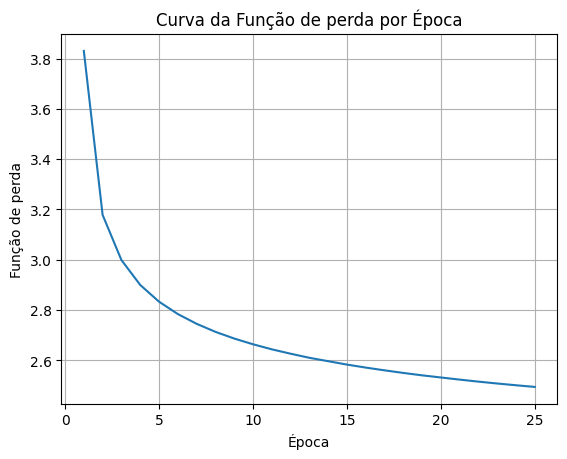

In [ ]:
epochs = list(range(1, len(losses) + 1))
plt.figure()
plt.plot(epochs, losses)
plt.xlabel('Época')
plt.ylabel('Função de perda')
plt.title('Curva da Função de perda por Época')
plt.grid(True)
plt.show()

## 7. Geração de Texto

### Geração autoregressiva de texto

A célula a seguir define a classe `TextGenerator`, responsável por gerar texto com o modelo `GPTMini` já treinado. A geração é feita de forma autoregressiva: o modelo recebe um `prompt`, prevê uma distribuição para o próximo token, sorteia um novo token, adiciona esse token ao texto e repete o processo.

A classe usa o vocabulário aprendido anteriormente para fazer duas conversões importantes:

- índice $\rightarrow$ token, usando `idx_to_word`;
- token $\rightarrow$ índice, usando `word_to_idx`.

Os principais métodos da classe são:

- `__init__`: inicializa o gerador de texto.

  Esse método recebe:

  - `idx_to_word`: lista que converte IDs inteiros em tokens;
  - `temperature`: temperatura padrão usada na amostragem.

  A partir de `idx_to_word`, o método também cria o dicionário inverso `word_to_idx`, usado para converter os tokens do `prompt` em IDs inteiros.

- `_tokenize`: converte um texto bruto em uma lista de tokens.

  Esse método:

  - converte o texto para letras minúsculas;
  - aplica `pad_punctuation`, separando pontuações por espaços;
  - divide o texto em tokens usando espaços.

  Por exemplo, um prompt como:

  ```text
  wine review : italy
  ```

  é convertido em uma lista de tokens:

  ```text
  ["wine", "review", ":", "italy"]
  ```

- `_sample`: sorteia o próximo token a partir de uma distribuição de probabilidades.

  Esse método recebe um vetor de probabilidades sobre o vocabulário e ajusta essa distribuição usando a temperatura:

  $$
  \tilde{p}_j
  =
  \dfrac{p_j^{1/\tau}}{\sum_k p_k^{1/\tau}}
  =
  \texttt{softmax}\left(\dfrac{z}{\tau}\right)_j,
  $$

  em que $\tau$ é a temperatura, $p_j=\texttt{softmax}\left( z \right)_j$ é a probabilidade original do token $j$, e $\tilde{p}_j$ é a probabilidade ajustada. A igualdade com a softmax dos *logits* divididos por $\tau$ vale porque a distribuição original $p$ foi obtida a partir de uma softmax aplicada aos *logits* $z$.

  Em termos intuitivos:

  - `temperature < 1`: aumenta a concentração nos tokens mais prováveis;
  - `temperature = 1`: mantém a distribuição original;
  - `temperature > 1`: torna a distribuição mais espalhada, aproximando-a de uma distribuição uniforme e aumentando a diversidade.

  Depois do ajuste, o método usa `torch.multinomial` para sortear um ID de token de acordo com a distribuição ajustada.

- `generate`: gera texto passo a passo a partir de um `prompt`.

  Primeiro, o modelo é colocado em modo de avaliação com `model.eval()`. Isso é importante porque desativa comportamentos usados apenas no treinamento, como `Dropout`.

  Em seguida, o `prompt` é tokenizado e convertido em uma lista de IDs:

  $(\mathrm{ID}_1,\mathrm{ID}_2,\ldots,\mathrm{ID}_S).$

  Tokens que não aparecem no vocabulário são mapeados para o índice `1`, correspondente ao token desconhecido (`[UNK]`).

  A cada passo de geração, a lista de IDs é transformada em um tensor com forma `[1, S]`, representando um lote com uma única sequência. Esse tensor é passado ao modelo:

  $\text{log_probs}, \text{attn} = \mathrm{GPTMini}(x).$

  O tensor `log_probs` contém log-probabilidades para todos os tokens do vocabulário em cada posição da sequência. Para gerar o próximo token, usamos apenas a última posição da sequência atual, correspondente a $\mathrm{ID}_S$. Em termos de código, essa posição é acessada com índice `-1`.

  Essa última posição fornece:

  $\log p_\theta(\mathrm{ID}_{S+1}=j \mid \mathrm{ID}_1,\ldots,\mathrm{ID}_S), \qquad j=0,\ldots,V-1.$

  Essas log-probabilidades são convertidas em probabilidades com `exp()`:

  $p_\theta(\mathrm{ID}_{S+1} = j \mid \mathrm{ID}_1,\ldots,\mathrm{ID}_S).$

  Em seguida, `_sample` sorteia o próximo ID de token. O novo ID é adicionado ao contexto, e o token correspondente é concatenado ao texto gerado.

  O processo continua até que uma das condições de parada seja satisfeita:
  
  - o comprimento total da sequência, incluindo o `prompt` e os tokens gerados, atinge `max_tokens`;
  - o modelo gera o token de padding, cujo ID é `0`.

  Durante a geração, o método também armazena informações em uma lista chamada `info`. Em cada passo, essa lista guarda:

  - o texto gerado até aquele momento;
  - as probabilidades previstas para o próximo token;
  - os pesos de atenção associados à última posição da sequência.

  Essas informações podem ser usadas depois para visualizar quais tokens receberam mais atenção e quais eram os próximos tokens mais prováveis em cada passo.

O processo implementado pela classe segue a fatoração autoregressiva:

$p_\theta(\mathrm{ID}_1,\ldots,\mathrm{ID}_T) = \prod\limits_{t=1}^{T} p_\theta(\mathrm{ID}_t \mid \mathrm{ID}_{<t}).$

Portanto, a geração autoregressiva consiste em construir uma sequência token por token, sempre usando os tokens já gerados como contexto para prever o próximo.

In [ ]:
# CLASSE TextGenerator – gera texto passo a passo com o modelo treinado
class TextGenerator:
    """
    Gera texto autoregressivamente com base num modelo treinado.

    Attributes
    ----------
    idx_to_word : list[str]
        Lista de mapeamento índice → palavra.
    word_to_idx : dict[str, int]
        Dicionário de mapeamento palavra → índice.
    default_temperature : float
        Temperatura padrão de amostragem.
    """

    def __init__(self, idx_to_word: list[str], temperature: float = 1.0):
        self.idx_to_word = idx_to_word                                  # mapeamento índice → palavra
        self.word_to_idx = {w: i for i, w in enumerate(idx_to_word)}    # dicionário inverso palavra → índice
        self.default_temperature = temperature                          # temperatura padrão de amostragem

    def _tokenize(self, txt: str) -> list[str]:
        """
        Converte texto cru em lista de tokens:
        - converte em letras minúsculas
        - aplica espaçamento em pontuação
        - divide em tokens por espaços

        Parameters
        ----------
        txt : str
            Texto de entrada.

        Returns
        -------
        list[str]
            Lista de tokens.
        """
        return pad_punctuation(txt.lower()).split()

    def _sample(self, probs: torch.Tensor, temperature: float) -> int:
        """
        Sorteia 1 token a partir de uma distribuição de probabilidade com temperatura.
        """
        probs = (probs ** (1 / temperature))        # aplica temperatura (↑temp = distribuição mais "uniforme")
        probs = probs / probs.sum()                 # re-normaliza para somar 1
        return torch.multinomial(probs, 1).item()   # amostra 1 índice segundo a distribuição ajustada

    @torch.no_grad()                                # desliga gradiente (inferência)
    def generate(
        self,
        model,                                      # modelo MiniGPT
        prompt: str,                                # texto inicial
        max_tokens: int = MAX_LEN,                  # comprimento máximo total
        temperature: float | None = None            # temperatura opcional por chamada
    ) -> list[dict]:                                # devolve lista de dicionários com stats de cada passo
        """
        Gera texto passo a passo e coleta estatísticas de atenção e distribuição.
        """

        model.eval()        # ativa modo de avaliação (desliga dropout, batchnorm, etc.)

        temp = self.default_temperature if temperature is None else temperature     # decide temperatura
        ids = [self.word_to_idx.get(t, 1) for t in self._tokenize(prompt)]          # prompt → lista de índices (1=<unk>)

        info: list[dict] = []                               # lista onde cada item = stats de um passo
        while len(ids) < max_tokens and ids[-1] != 0:       # pára ao atingir o tamanho máximo ou o token <pad>
            x = torch.tensor([ids], device=DEVICE)          # cria batch (1, S) e move p/ DEVICE
            log_probs, attn = model(x)                      # forward: obtém log_probs (1, S, V) e pesos de atenção

            # Extrai os pesos de atenção da última posição, isto é, do token que acabou de ser gerado (posição final). attn pode ser 3D ou 4D.
            if attn.ndim == 4:                                          # saída (B, heads, S, S) caso average_attn_weights = False
                step_atts = attn[0, :, -1, :].cpu().numpy()             # pega [batch=0, todas as cabeças, token alvo=-1, todas as posições de contexto]
            else:                                                       # saída (batch, S, S) caso average_attn_weights = True
                step_atts = attn[0, -1, :].unsqueeze(0).cpu().numpy()   # pega [batch=0, token alvo=-1, todas as posições de contexto], e recria uma dimensão de "heads"=1

            # Amostra o próximo token com temperatura
            probs = log_probs[0, -1].exp()                    # converte log-probabilidades → probabilidades
            next_id = self._sample(probs, temp)               # sorteia índice

            # Armazena informações do passo atual para posterior visualização
            info.append({
                "prompt": prompt,                   # texto gerado até antes de acrescentar next_id
                "word_probs": probs.cpu().numpy(),  # vetor de probabilidades p/ próximo token
                "atts": step_atts                   # mapa de atenção (heads, S)
            })

            ids.append(next_id)                         # adiciona token sorteado ao contexto
            prompt += " " + self.idx_to_word[next_id]   # concatena palavra ao texto exibido

        # Exibe o resultado completo
        print("Texto gerado:")
        display(prompt)

        return info                            # devolve lista com stats de todos os passos

### Visualização de probabilidades e atenção

A célula a seguir define uma função para visualizar informações coletadas durante a geração. Para cada passo, ela mostra o texto gerado com destaque proporcional aos pesos de atenção e lista os tokens mais prováveis para a próxima posição.

Os pesos de atenção indicam quais posições anteriores receberam maior peso no cálculo da representação usada para prever o próximo token.

In [ ]:
def print_probs(info, vocab, top_k: int = 5):
    """
    Exibe:
      • frase gerada com realce de atenção (HTML)
      • top-k palavras mais prováveis no passo atual
    Parâmetros
    ----------
    info  : list[dict]  lista produzida por TextGenerator.generate()
    vocab : list[str]   mapeamento índice → palavra
    top_k : int         quantas palavras mostrar no ranking de probabilidades
    """
    for i in info:                                                   # percorre cada passo de geração
        highlighted_text = []                                        # armazenará o texto com cores de atenção


        # 1) gera HTML que colore cada palavra conforme o score de atenção
        for word, att_score in zip(
            i["prompt"].split(),                                     # palavras já geradas
            np.mean(i["atts"], axis=0)                               # atenção média da palavra alvo
        ):
            highlighted_text.append(                                 # cria um <span> colorido p/ cada palavra
                '<span style="background-color:rgba(135,206,250,'    # cor: azul-claro com alfa variável
                + str(att_score / max(np.mean(i["atts"], axis=0)))   # → normaliza pelo máx. do vetor
                + ');">'
                + word                                               # texto da palavra
                + "</span>"
            )

        highlighted_text = " ".join(highlighted_text)                # junta spans em uma string HTML
        display(HTML(highlighted_text))                              # mostra no notebook


        # 2) imprime top-k probabilidades da próxima palavra
        word_probs = i["word_probs"]                                 # vetor de probabilidades (float32, len = V)
        p_sorted = np.sort(word_probs)[::-1][:top_k]                 # top-k valores decrescentes
        i_sorted = np.argsort(word_probs)[::-1][:top_k]              # índices correspondentes

        for p, idx in zip(p_sorted, i_sorted):                       # percorre pares (prob, índice)
            print(f"{vocab[idx]}:\t{np.round(100 * p, 2)}%")         # exibe palavra e probabilidade %
        print("--------\n")                                          # linha separadora

### Criação do gerador de texto

A célula a seguir instancia `TextGenerator` usando o vocabulário aprendido. O gerador precisa do vocabulário para converter índices em palavras durante a geração e palavras em índices durante a leitura do `prompt`.

In [ ]:
# Instancia o gerador de texto
text_generator = TextGenerator(vocab)

### Geração com prompt referente aos Estados Unidos

A célula a seguir gera uma resenha sintética iniciada pelo prompt `"wine review : us"`.

In [ ]:
info = text_generator.generate(model, "wine review : us", max_tokens=80, temperature=1.0)

Texto gerado:


'wine review : us : virginia : seyval blanc : elegant aromas of citrus and tropical fruit dominate , with a tingly note of peach . the palate feels slack , featuring savory apple and peach gently . this feels ; a bit thin , then turns [UNK] in acid with the pickled jalapeño tang charging acids . an soft finish closes the short . drink now . christopher cannan selection , 300 cases imported . it is very interesting'

### Geração com prompt referente à Itália

A célula a seguir gera texto a partir do prompt `"wine review : italy"`.

In [ ]:
info = text_generator.generate(model, "wine review : italy", max_tokens=80, temperature=0.5)

Texto gerado:


"wine review : italy : tuscany : red blend : this blend of cabernet sauvignon and merlot opens with aromas of leafy underbrush , tobacco and a whiff of game . the palate offers dried black cherry , espresso and mint alongside astringent tannins . it ' s still young and will develop more complexity over the next few years . drink 2019–2025 . the results . the wine is a wine to capture the remaining fruit . drink soon"

### Geração com prompt referente à Alemanha e inspeção das probabilidades

A célula a seguir gera uma resenha sintética iniciada por `"wine review : germany"` e depois chama `print_probs` para visualizar, passo a passo, as palavras mais prováveis e os pesos de atenção associados ao contexto.

In [ ]:
info = text_generator.generate(model, "wine review : germany", max_tokens=80, temperature=0.5)
print_probs(info, vocab)

Texto gerado:


"wine review : germany : mosel : riesling : while this is a gorgeously fruity , off - dry riesling is a bit of sugar and dried herbs distract . it ' s juicy and fruity on the palate , with a lingering finish . drink now . enjoy now through 2020 . drink now . enjoy now . enjoy through 2020 . it through 2020 . a decade . drink now . imported by freixenet usa . importers ."

::	100.0%
zealand:	0.0%
pinot:	0.0%
of:	0.0%
to:	0.0%
--------



mosel:	33.369998931884766%
rheinhessen:	27.860000610351562%
rheingau:	18.6200008392334%
franken:	5.619999885559082%
pfalz:	5.5%
--------



::	97.44999694824219%
-:	2.4600000381469727%
.:	0.019999999552965164%
other:	0.009999999776482582%
(:	0.009999999776482582%
--------



...

chapin:	24.15999984741211%
[UNK]:	22.020000457763672%
freixenet:	21.6299991607666%
tom:	6.940000057220459%
republic:	5.690000057220459%
--------



usa:	62.27000045776367%
.:	13.140000343322754%
,:	12.869999885559082%
[UNK]:	2.990000009536743%
is:	1.409999966621399%
--------



.:	96.58000183105469%
,:	1.0%
wine:	0.4000000059604645%
wines:	0.25%
that:	0.1899999976158142%
--------



importers:	20.979999542236328%
c:	14.8100004196167%
[UNK]:	8.319999694824219%
panebianco:	6.900000095367432%
edward:	3.130000114440918%
--------



.:	95.91999816894531%
,:	2.680000066757202%
;:	0.23000000417232513%
[UNK]:	0.18000000715255737%
but:	0.10999999940395355%
--------



## 8. Avaliação

### Cálculo da *perplexity*

A célula a seguir define uma função para avaliar o modelo por meio da *perplexity*. Primeiro, calcula-se a NLL média por token não-padding no conjunto avaliado:

$$
\overline{\mathrm{NLL}}
=
-\frac{1}{M}
\sum_{i=1}^{M}
\log p_\theta(y_i \mid \text{contexto}_i),
$$

em que $M$ é o número de tokens válidos. Em seguida, a *perplexity* é:

$$
\mathrm{PPL} = \exp(\overline{\mathrm{NLL}}).
$$

Quanto menor a perplexidade, melhor o modelo está, em média, em atribuir alta probabilidade aos próximos tokens corretos.

In [ ]:
def compute_perplexity(model, data_loader):
    """
    Calcula a perplexidade de um modelo auto-regressivo em um conjunto de dados.

    A função percorre todos os lotes do data_loader, acumula a soma do NLL
    sobre todos os tokens não-PAD e, ao final, computa:

        avg_nll = NLL média por token
        perplexity = exp(avg_nll)

    Parameters
    ----------
    model : torch.nn.Module
        Modelo já treinado que recebe tensores [B, S] e retorna
        log-probabilidades [B, S, V] (além de pesos de atenção, se aplicável).
    data_loader : torch.utils.data.DataLoader
        DataLoader com lotes (x_batch, y_batch) usados para avaliação.

    Returns
    -------
    tuple of float
        avg_nll : NLL média por token não-PAD.
        ppl     : perplexidade correspondente (exp(avg_nll)).
    """

    model.eval()                                               # coloca o modelo em modo de avaliação
    total_loss = torch.tensor(0.0, device=DEVICE)              # acumula a soma da NLL sobre todos os tokens não-PAD
    total_tokens = torch.tensor(0.0, device=DEVICE)            # acumula o número total de tokens não-PAD usados no cálculo

    loss_fn = nn.NLLLoss(ignore_index=0,                       # NLLLoss ignorando o token <PAD> (ID 0), já que o modelo retorna log-probabilidades
                         reduction="sum")                      # reduction="sum": retorna a soma da NLL sobre os tokens válidos do lote

    with torch.no_grad():                                      # bloco sem cálculo de gradiente (apenas avaliação)
        for x_batch, y_batch in data_loader:                   # percorre todos os lotes (x, y) do data_loader
            x_batch = x_batch.to(DEVICE)                       # move o lote de entradas para o dispositivo
            y_batch = y_batch.to(DEVICE)                       # move o lote de alvos para o dispositivo

            log_probs, _ = model(x_batch)                      # obtém log-probabilidades do modelo: [B, S, V]

            loss = compute_nll_logprobs(                       # NLL somada sobre todos os tokens não-PAD do lote (escalares)
                log_probs,
                y_batch,
                loss_fn
            )

            total_loss += loss                                 # acumula a soma das perdas de todos os lotes
            total_tokens += (y_batch != 0).sum()               # acumula quantos tokens não são <PAD> (ID 0) em todo o data_loader

    avg_nll = total_loss / total_tokens                        # NLL média por token não-PAD em todo o conjunto avaliado
    ppl = torch.exp(avg_nll)                                   # perplexidade = exp(NLL média por token)

    return avg_nll.item(), ppl.item()                          # devolve valores escalares em float (para impressão / logging)

### Avaliação no conjunto de teste

A célula a seguir calcula a NLL média e a *perplexity* do MiniGPT no conjunto de teste.

In [ ]:
test_nll_gpt, test_ppl_gpt = compute_perplexity(model, test_dl)
print(f"MiniGPT NLL: {test_nll_gpt:.4f}, MiniGPT PPL: {test_ppl_gpt:.2f}")

MiniGPT NLL: 2.6508, MiniGPT PPL: 14.16


# Tarefa (em duplas)

**Treinar um MiniGPT com receitas do *Epicurious* e compará-lo às redes neurais recorrentes do Laboratório 5**

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Substitua as resenhas de vinho pela base [Epicurious - Recipes with Rating and Nutrition](https://www.kaggle.com/datasets/hugodarwood/epirecipes) usada no Laboratório 5, reaproveitando daquele laboratório o carregamento, a filtragem e a classe `EpicuriousRecipesDataset` (com `vocab = ds.itos`), além de `VOCAB_SIZE`, `MAX_LEN`, `EMBEDDING_DIM` e a divisão dos conjuntos de treinamento/teste. Treine o `GPTMini` com os demais hiperparâmetros do código acima: esta é a **configuração base**, referência para as comparações seguintes.

**Treine todos os modelos com `EPOCHS=25`, `BATCH_SIZE=32` e `LEARNING_RATE=1e-3`, como no Laboratório 5, e crie, a cada experimento, um novo modelo e um novo otimizador logo após `torch.manual_seed(SEED)`.**

2. Varie, um de cada vez, os hiperparâmetros do bloco Transformador (`EMBEDDING_DIM`, `N_HEADS` e `FEED_FORWARD_DIM`), testando ao menos um valor menor e um maior que o da configuração base para cada um. Calcule a *perplexity* de cada modelo no conjunto de teste com `compute_perplexity` e reporte o efeito de cada hiperparâmetro.

   Obs.: Em [`nn.MultiheadAttention`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html), cada cabeça tem dimensão `EMBEDDING_DIM // N_HEADS`; por isso, `EMBEDDING_DIM` precisa ser divisível por `N_HEADS`.

3. Com a configuração base, fixe um *prompt* e gere um texto com cada valor de `temperature`: `0.1`, `0.5`, `1.0` e `1.5`.

4. Compare a *perplexity* e o número de parâmetros de todos os MiniGPTs com os das redes neurais recorrentes do Laboratório 5.

   Obs.: *perplexities* só são comparáveis se calculadas da mesma forma (NLL média por token, ignorando o *padding*), com o mesmo vocabulário e no mesmo conjunto de teste.

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 6 — MiniGPT**, que deve conter:

- **Setup**: dados utilizados (corpus, filtragem, `VOCAB_SIZE`, `MAX_LEN` e
  tamanho do lote), arquitetura do `GPTMini` na configuração base
  (`EMBEDDING_DIM`, `N_HEADS` e `FEED_FORWARD_DIM`) e hiperparâmetros de
  treinamento (função de perda, otimizador, taxa de aprendizado e número de
  épocas). Apresente também uma tabela listando os experimentos realizados e,
  em cada um, o que foi alterado em relação à configuração base.
- **Resultados**:
  - *perplexity* no conjunto de teste de cada experimento (pode ser uma coluna
    da tabela do Setup);
  - tabela com o número de parâmetros e a *perplexity* no teste do melhor
    MiniGPT e das redes recorrentes do Laboratório 5.
- **Análise**: texto breve (5-10 linhas) discutindo, a partir das tabelas e dos
  textos gerados, qual hiperparâmetro do bloco Transformador mais afetou a
  *perplexity*, como a temperatura altera a coerência e a diversidade dos
  textos, e se o MiniGPT supera as RNNs nesse experimento, considerando também o
  número de parâmetros de cada modelo.

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.